In [17]:
"""
Created on: 18-08-2026

@author B.A. Sturre

PyTorch tutorial 
https://www.youtube.com/watch?v=c36lUUr864M 
"""

import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

## Feed forward net

In [ ]:
# device configuration: run on gpu if supported (it's not)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyper parameters 
input_size = 784  # 28x28 flattened
hidden_size = 100
num_classes = 10  # 10 digits (0-9)
num_epochs = 2 
batch_size = 100
learning_rate = 0.001

# MNIST dataset 
train_dataset = torchvision.datasets.MNIST('./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST('./data', train=False, transform=transforms.ToTensor())

# data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

torch.Size([100, 1, 28, 28]) torch.Size([100])


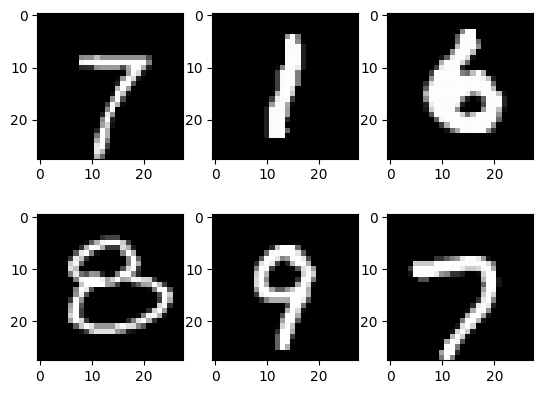

In [19]:
# example
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(samples[i][0], cmap='gray')
plt.show()

classifying the digits

In [23]:
class NeuralNet(nn.Module): 
    def __init__(self, input_size, hidden_size, num_classes): 
        super(NeuralNet, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x): 
        out = self.linear1(x)
        out = self.relu(out)
        out = self.linear2(out)
        # no softmax because we will apply CEL
        return out

model = NeuralNet(input_size, hidden_size, num_classes)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # reshaping images: 100, 1, 28, 28 -> 100, 784
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # forward 
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1)%100 == 0: 
            print(f'epoch {epoch+1} / {num_epochs}, step {i+1}/{n_total_steps}, loss = {loss.item():.4f}')

epoch 1 / 2, step 100/600, loss = 0.4690
epoch 1 / 2, step 200/600, loss = 0.3204
epoch 1 / 2, step 300/600, loss = 0.3007
epoch 1 / 2, step 400/600, loss = 0.3190
epoch 1 / 2, step 500/600, loss = 0.1707
epoch 1 / 2, step 600/600, loss = 0.2910
epoch 2 / 2, step 100/600, loss = 0.2255
epoch 2 / 2, step 200/600, loss = 0.1281
epoch 2 / 2, step 300/600, loss = 0.1972
epoch 2 / 2, step 400/600, loss = 0.1917
epoch 2 / 2, step 500/600, loss = 0.1352
epoch 2 / 2, step 600/600, loss = 0.1949


In [25]:
# test 
with torch.no_grad(): 
    n_correct = 0
    n_samples = 0 
    for images, labels in test_loader: 
        # reshaping images: 100, 1, 28, 28 -> 100, 784
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # calculating predictions 
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

    acc = 100.0 * n_correct / n_samples 
    print(f'accuracy = {acc:.2f}%')

accuracy = 95.39%
